# Predicción de ataque al corazón (Clasificación)

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [ ]:
#Cargamos los datos
data = pd.read_excel("ataque_corazon.xlsx", sheet_name="Datos")
data.head()

,age,hypertension,heart_disease,ever_married,avg_glucose_level,smoking_status,stroke_ataque_corazon
0,1,No,No,No,122.04,Unknown,No
1,79,No,No,Yes,79.03,Unknown,No
2,40,No,No,Yes,60.96,'never smoked',No
3,4,No,No,No,107.25,Unknown,No
4,8,No,No,No,106.51,Unknown,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5110 non-null   int64  
 1   hypertension           5110 non-null   object 
 2   heart_disease          5110 non-null   object 
 3   ever_married           5110 non-null   object 
 4   avg_glucose_level      5110 non-null   float64
 5   smoking_status         5110 non-null   object 
 6   stroke_ataque_corazon  5110 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 279.6+ KB


In [ ]:
#Corrección tipos de datos

data['hypertension']=data['hypertension'].astype('category')

data['heart_disease']=data['heart_disease'].astype('category')

data['ever_married']=data['ever_married'].astype('category')

data['smoking_status']=data['smoking_status'].astype('category')

data['stroke_ataque_corazon']=data['stroke_ataque_corazon'].astype('category')

data.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   age                    5110 non-null   int64   
 1   hypertension           5110 non-null   category
 2   heart_disease          5110 non-null   category
 3   ever_married           5110 non-null   category
 4   avg_glucose_level      5110 non-null   float64 
 5   smoking_status         5110 non-null   category
 6   stroke_ataque_corazon  5110 non-null   category
dtypes: category(5), float64(1), int64(1)
memory usage: 105.6 KB


In [ ]:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=True) # minimal=True
profile_data.to_file("reporte_ataque_corazon.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 157.69it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# **Dimensiones de la Calidad de Datos**

**Completitud:** ¿Está toda la información disponible? ¿Hay datos faltantes o ausentes?

**Exactitud:**¿La información es correcta y libre de error?

**Conformidad:** ¿Los valores de los datos están conformes con los formatos esperados? Ejemplo: Una fecha en formato AAAA/MM/DD cuando debería ser DD/MM/AAAA.

**Oportunidad:** ¿La información llega cuando se necesita?

**Duplicidad:** ¿Existen múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos?

**Integridad:** ¿Faltan datos relacionados importantes? ¿Es clara la conectividad y las relaciones con otros datos?

# **Diagnóstico de las dimensiones según el perfilado:**
* Completitud:  estan los datos completos
* Exactitud: no se evidencia
* Conformidad: no hay información de fechas
* Oportunidad: no se puedo verificar
* Duplicidad: no tenemos múltiples instancias, innecesarias de los mismos objetos de datos en el conjunto de datos
* Integridad: estan los datos completos

<Axes: xlabel='stroke_ataque_corazon'>

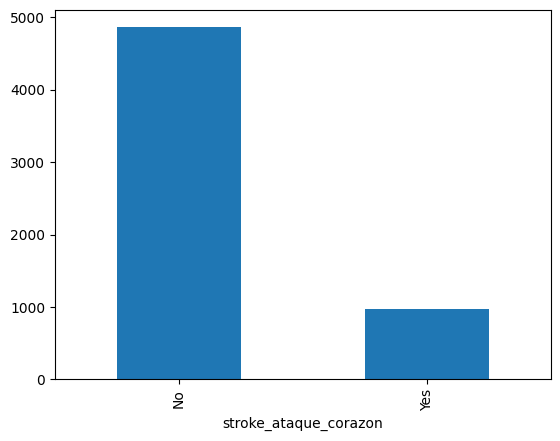

In [ ]:
#La clase minoritaria tendrá el 50% del tamaño de la clase mayoritaria, adicionando datos sintéticos
from imblearn.over_sampling import SMOTE, SMOTENC

#SMOTE: predictoras numéricas
#SMOTENC: al menos una predictora categórica

X = data.drop("stroke_ataque_corazon", axis = 1)
Y = data['stroke_ataque_corazon']

smote = SMOTENC(k_neighbors=2,  sampling_strategy=0.2, categorical_features=[1,2,3,5])
X_smote, y_smote = smote.fit_resample(X,Y)

# Creamos un dataframe con los resultados (X_smote, y_smote)
data  = pd.DataFrame(columns=X_smote.columns.values, data=X_smote)
data['stroke_ataque_corazon']=y_smote
data['stroke_ataque_corazon'].value_counts().plot(kind='bar')

In [ ]:
data = pd.get_dummies(data, columns=['smoking_status'], drop_first=True, dtype=int)
data = pd.get_dummies(data, columns=['hypertension','heart_disease','ever_married',], drop_first=True, dtype=int)

data.head()

,age,avg_glucose_level,stroke_ataque_corazon,smoking_status_'never smoked',smoking_status_Unknown,smoking_status_smokes,hypertension_Yes,heart_disease_Yes,ever_married_Yes
0,1,122.04,No,0,1,0,0,0,0
1,79,79.03,No,0,1,0,0,0,1
2,40,60.96,No,1,0,0,0,0,1
3,4,107.25,No,0,1,0,0,0,0
4,8,106.51,No,0,1,0,0,0,0


In [ ]:
#LabelEncoder para la variable objetivo
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data["stroke_ataque_corazon"]=labelencoder.fit_transform(data["stroke_ataque_corazon"])
data.head()

,age,avg_glucose_level,stroke_ataque_corazon,smoking_status_'never smoked',smoking_status_Unknown,smoking_status_smokes,hypertension_Yes,heart_disease_Yes,ever_married_Yes
0,1,122.04,0,0,1,0,0,0,0
1,79,79.03,0,0,1,0,0,0,1
2,40,60.96,0,1,0,0,0,0,1
3,4,107.25,0,0,1,0,0,0,0
4,8,106.51,0,0,1,0,0,0,0


libreria que solo trabaja con variables numericas : skleain
sirve para los:  

arbol
random forest
KNN
svm

# 2. División 70-30


<Axes: xlabel='stroke_ataque_corazon'>

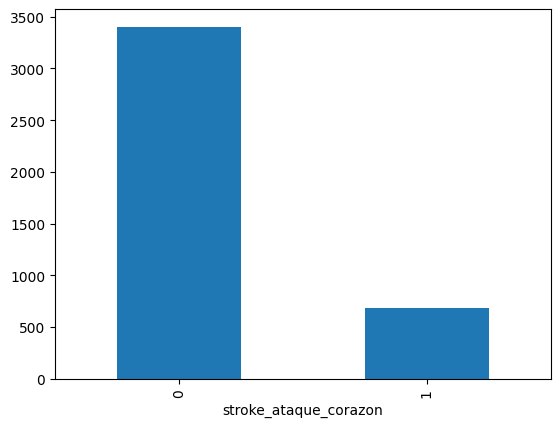

In [ ]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data.drop("stroke_ataque_corazon", axis = 1) # Variables predictoras
Y = data['stroke_ataque_corazon'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado
Y_train.value_counts().plot(kind='bar')

stratify = Y ; muestreo estraticado: mantener la proporcion de los estratos (Categorias) va en **YES en clasificación; cuando es regresión va en NO**

<Axes: xlabel='stroke_ataque_corazon'>

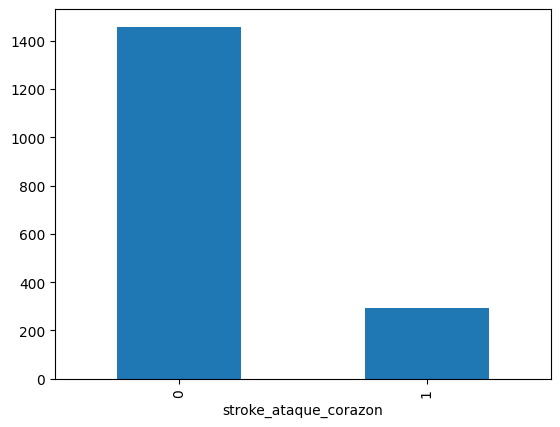

In [ ]:
#Variable objetivo del 30%
Y_test.value_counts().plot(kind='bar')

# 3. Aprendizaje con el 70% y Evaluación con el 30%


# **Tree**
No se normaliza, porque si los normalizo pierden explicabilidad del modelo cuando se normalice

In [ ]:

#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=50, max_depth=10) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train

DecisionTreeClassifier(max_depth=10, min_samples_leaf=50)

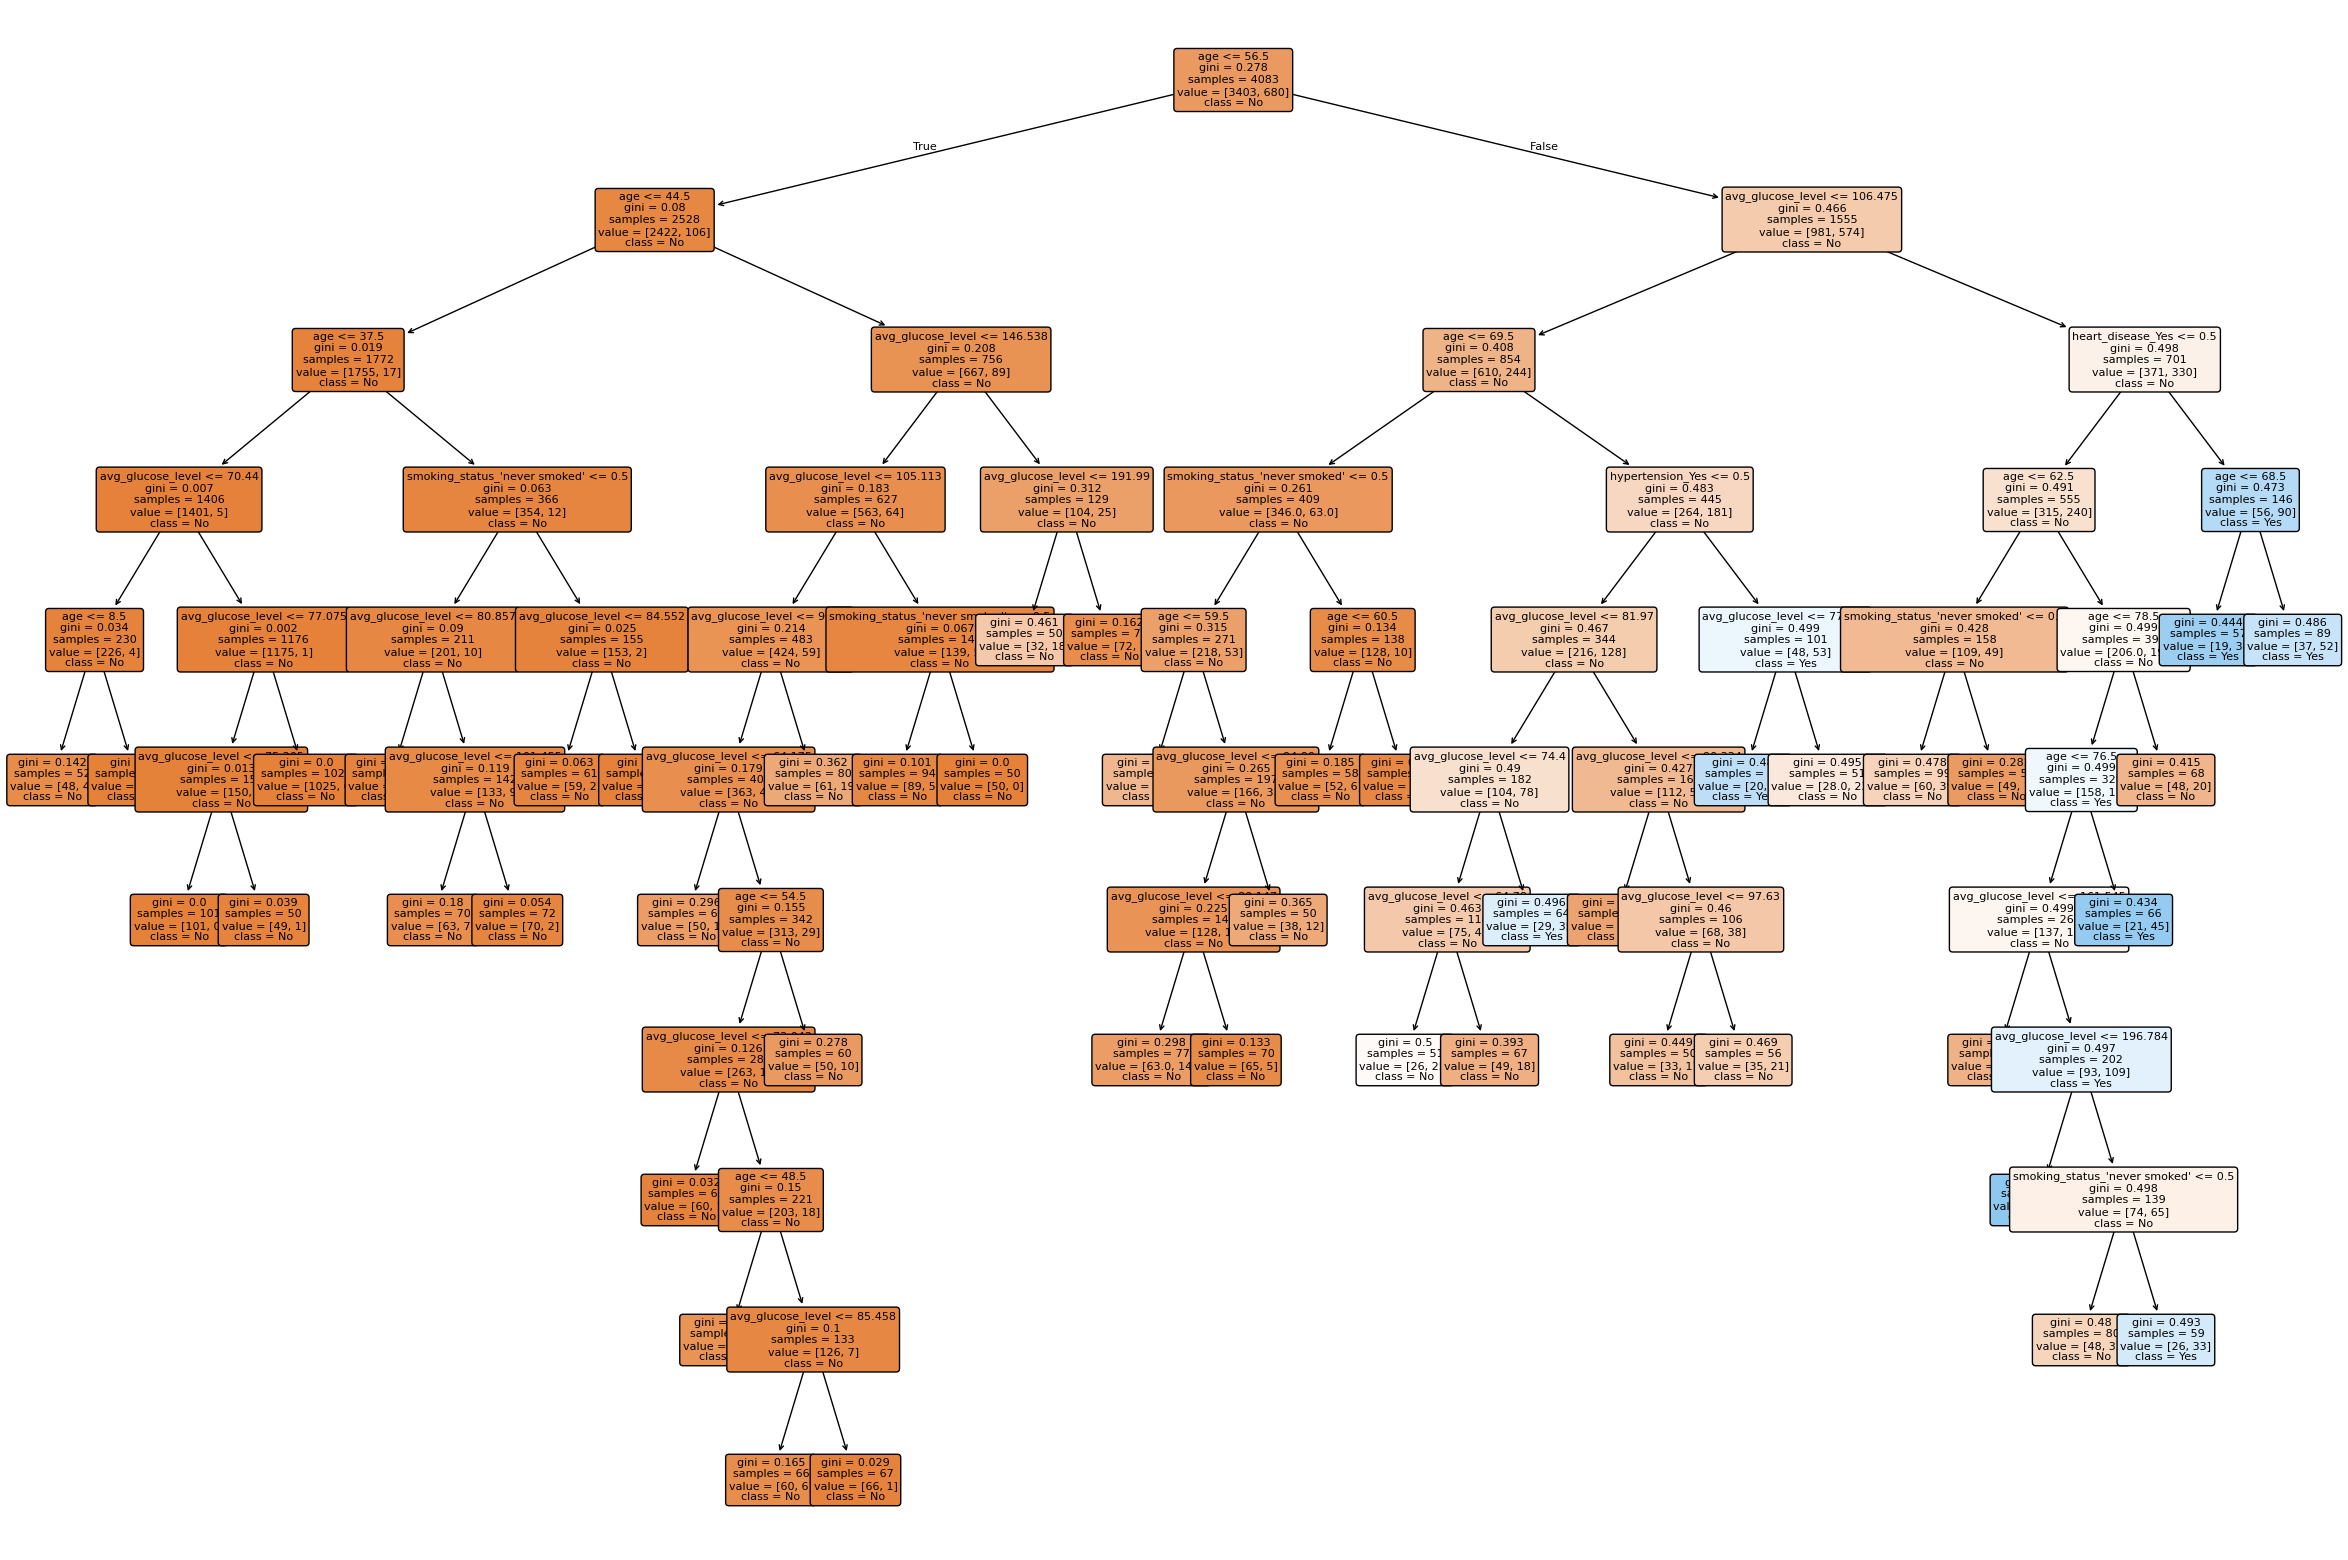

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=labelencoder.classes_, rounded=True,  fontsize=8, filled=True)
plt.show()

In [ ]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[0 0 0 ... 0 0 0]


Salen ceros por labelencore

In [ ]:
Exactitud: total de correctos

In [ ]:
#Exactitud: Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.844


In [ ]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[1369,   89],
       [ 184,  108]])

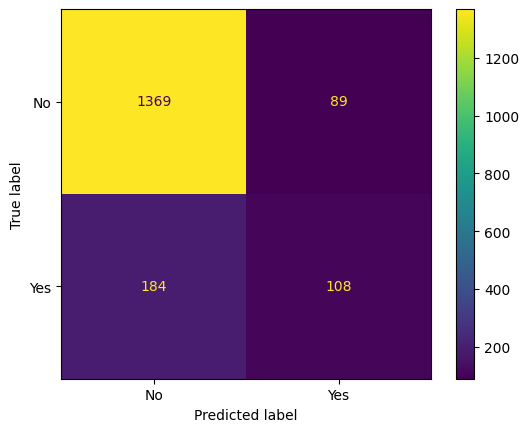

In [ ]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

In [ ]:
#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

              precision    recall  f1-score   support

          No       0.88      0.94      0.91      1458
         Yes       0.55      0.37      0.44       292

    accuracy                           0.84      1750
   macro avg       0.71      0.65      0.68      1750
weighted avg       0.83      0.84      0.83      1750



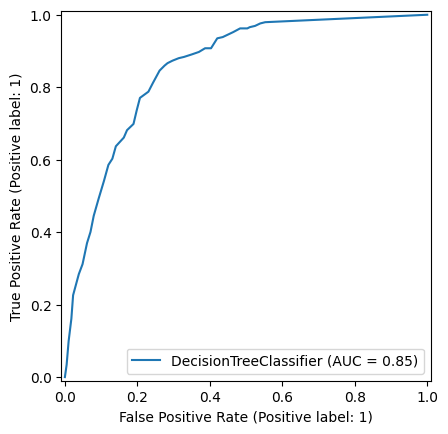

In [ ]:
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

# **Random Forest**
No se normaliza

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.9, criterion='gini',
                              max_depth=20, min_samples_leaf=10)
model_rf.fit(X_train, Y_train) #70%

RandomForestClassifier(max_depth=20, max_samples=0.9, min_samples_leaf=10,
                       n_estimators=200)

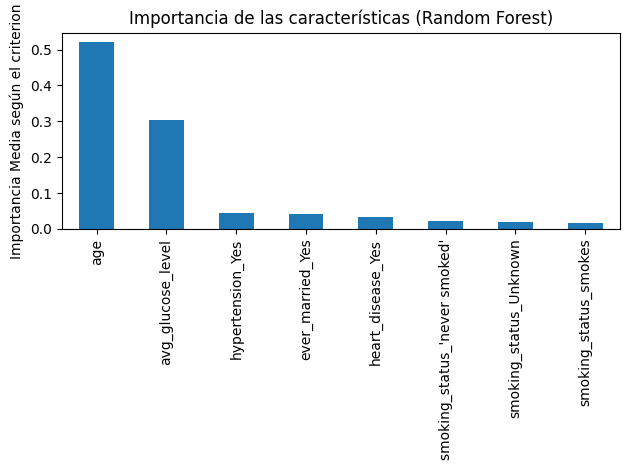

In [ ]:
#Importancia de las características
importances = model_rf.feature_importances_
feature_names = X_train.columns
forest_importances = pd.Series(importances, index=feature_names)

fig, ax = plt.subplots()
forest_importances.sort_values(ascending=False).plot.bar(ax=ax)
ax.set_title("Importancia de las características (Random Forest)")
ax.set_ylabel("Importancia Media según el criterion")
fig.tight_layout()
plt.show()

              precision    recall  f1-score   support

          No       0.89      0.98      0.93      1458
         Yes       0.77      0.38      0.51       292

    accuracy                           0.88      1750
   macro avg       0.83      0.68      0.72      1750
weighted avg       0.87      0.88      0.86      1750



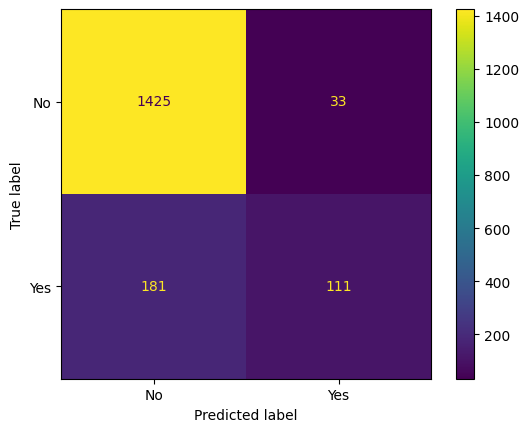

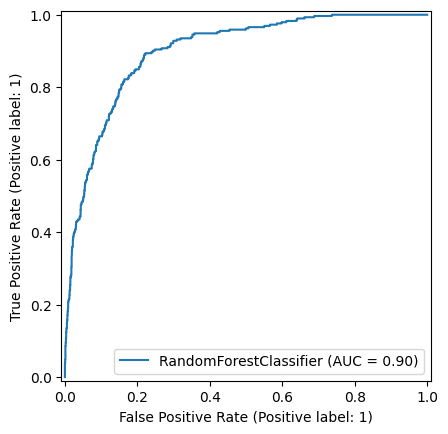

In [ ]:
#Evaluación de RandomForest con 30%
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(model_rf,X_test, Y_test)

In [ ]:
model_rf= RandomForestClassifier(n_estimators=200,  max_samples=0.8, criterion='gini',
                              max_depth=24, min_samples_leaf=2)
model_rf.fit(X_train, Y_train) #70%

RandomForestClassifier(max_depth=24, max_samples=0.8, min_samples_leaf=2,
                       n_estimators=200)

              precision    recall  f1-score   support

          No       0.92      0.96      0.94      1458
         Yes       0.74      0.58      0.65       292

    accuracy                           0.90      1750
   macro avg       0.83      0.77      0.79      1750
weighted avg       0.89      0.90      0.89      1750



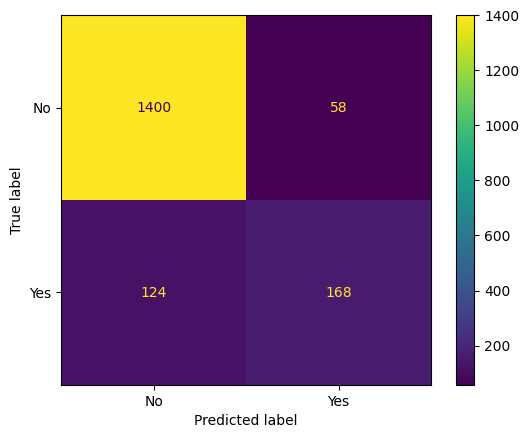

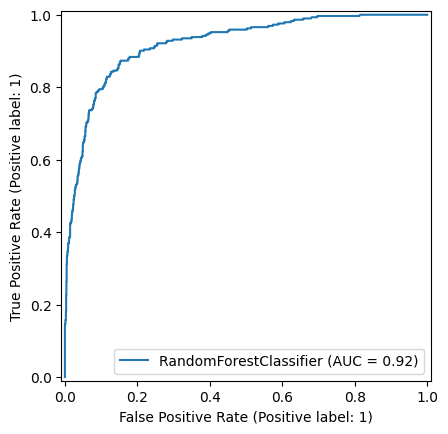

In [ ]:
#Evaluación de RandomForest con 30%
from sklearn import metrics

Y_pred = model_rf.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(model_rf,X_test, Y_test)

# **KNN**
* Normalización

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['age','avg_glucose_level']


min_max_scaler.fit(data[variables_numericas]) #Ajuste de los parametros sobre 100% de los datos (data): max - min

#Se aplica la normalización a 70%  y 30%
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,age,avg_glucose_level,smoking_status_'never smoked',smoking_status_Unknown,smoking_status_smokes,hypertension_Yes,heart_disease_Yes,ever_married_Yes
5006,0.691358,0.747669,0,1,0,0,1,0
4455,0.629630,0.140984,1,0,0,0,1,1
1462,0.345679,0.071046,0,1,0,0,0,1
224,0.000000,0.024975,0,1,0,0,0,0
4692,0.679012,0.655433,0,0,0,0,0,1


In [ ]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

              precision    recall  f1-score   support

          No       0.94      0.92      0.93      1458
         Yes       0.64      0.68      0.66       292

    accuracy                           0.88      1750
   macro avg       0.79      0.80      0.80      1750
weighted avg       0.89      0.88      0.88      1750



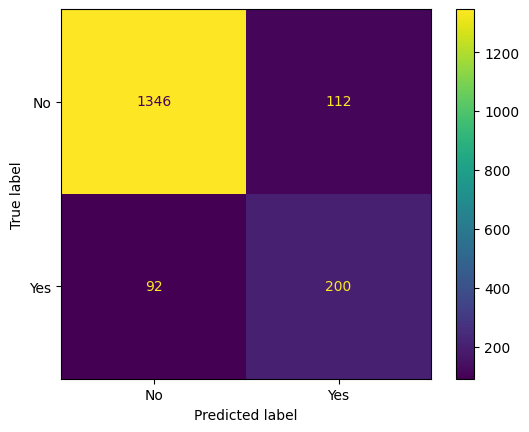

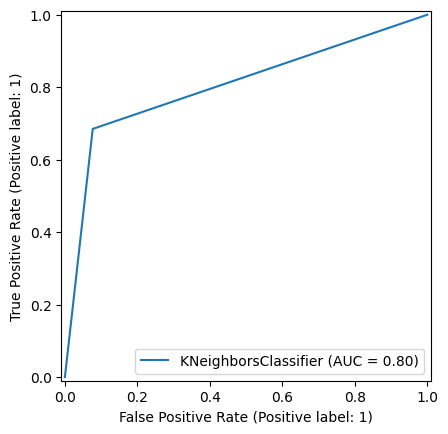

In [ ]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)

In [ ]:
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

              precision    recall  f1-score   support

          No       0.94      0.92      0.93      1458
         Yes       0.64      0.68      0.66       292

    accuracy                           0.88      1750
   macro avg       0.79      0.80      0.80      1750
weighted avg       0.89      0.88      0.88      1750



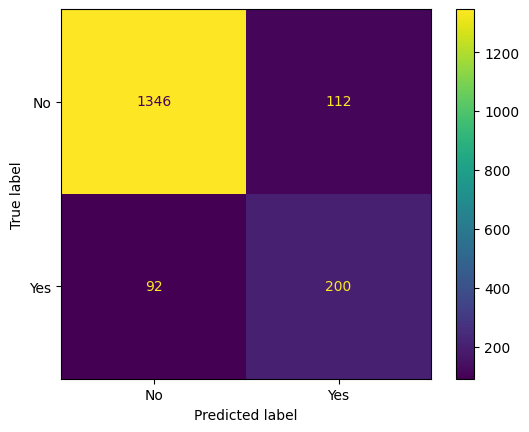

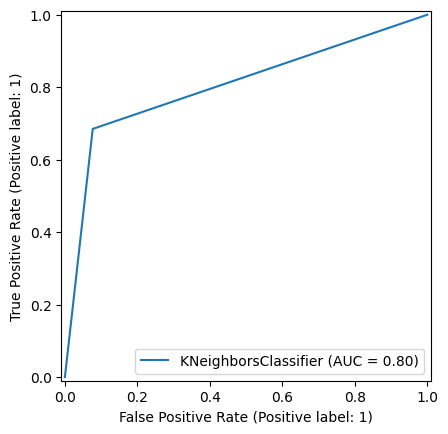

In [ ]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)

# **Red Neuronal**
- Normalizar

# **SVM**
-Normalizar

# 5. Guardamos el mejor modelo


**Selecion del modelo:**
1. Calidad de los modelos: Knn, NN y Tree desempeño parecido en recall
2. Complejidad computacional: Tree mas liviano computacionalmente

**Selección del modelo:**

In [ ]:
modelo_final=modelSVM

Se entrena modelo final con 100% de los datos (X,Y)

In [ ]:
# Si selecciona Knn, NN, SVM, Reg -> se debe normalzar X (100% de los datos)
# Si selecciona Tree no se normaliza y se comenta la siguiente línea
X[variables_numericas]= min_max_scaler.transform(X[variables_numericas])

In [ ]:
#Entrenamos modelo final
modelo_final.fit(X, Y) #100%

In [ ]:
import pickle
filename = 'modelo-class.pkl'
variables= X.columns._values
pickle.dump([modelo_final, labelencoder,variables,min_max_scaler], open(filename, 'wb'))

